## Day 1 — First Living Market

Goal:
Build the smallest possible agent-driven market simulation.

Questions:
- Can agent interaction alone create meaningful price movement?
- What happens if agents react to recent price changes?
- Can simple rules create emergent behavior?

In [44]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")

from agents.agent import Agent
from market.market import Market

In [45]:
agents = []
for i in range(1,100):
    cash = rd.uniform(0,1000)
    holdings = rd.randint(0, 100)
    risk_tolerance = rd.uniform(0, 1)
    agent = Agent(i,cash,holdings,risk_tolerance)
    agents.append(agent)



In [46]:
current_price = 12
price_movement = 0
sensitivity = 0.1
market = Market(current_price,sensitivity)
T = 100
for t in range(T):

    actions = []

    for agent in agents:
        act, vol = agent.action(current_price, price_movement)
        actions.append((act, vol))

    market.agents_act(actions)

    price = market.pricing()
    price_movement = price - current_price
    current_price = price

In [47]:
prices = []
imbalances = []
returns = []
buy_pressure = []
sell_pressure = []

In [48]:
for snapshot in market.price_history:
    prices.append(snapshot[0])
    imbalances.append(snapshot[1])
    returns.append(snapshot[2])
    buy_pressure.append(snapshot[3])
    sell_pressure.append(snapshot[4])

Text(0, 0.5, 'Price')

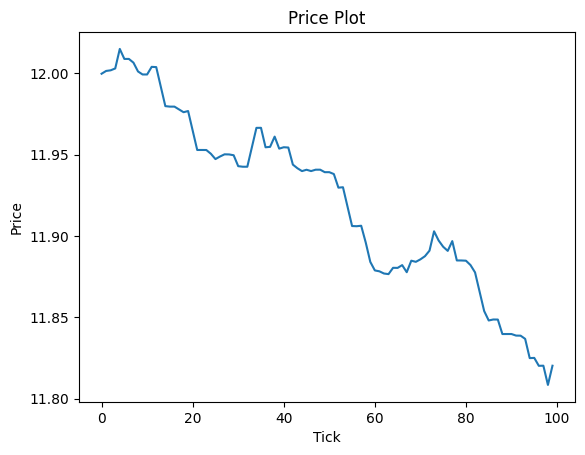

In [49]:
plt.plot(prices)
plt.title("Price Plot")
plt.xlabel("Tick")
plt.ylabel("Price")

Text(0, 0.5, 'Return')

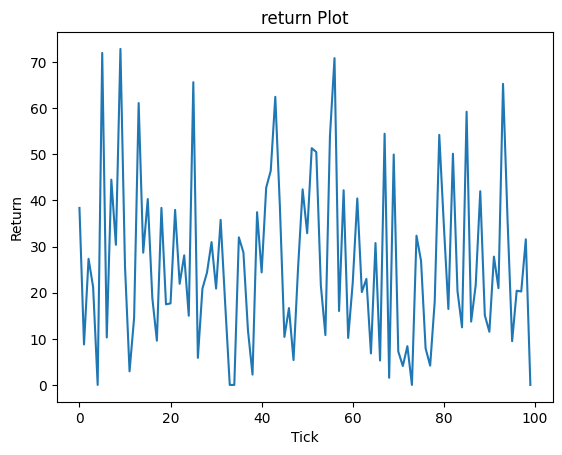

In [50]:
plt.plot(returns)
plt.title("return Plot")
plt.xlabel("Tick")
plt.ylabel("Return")

Text(0, 0.5, 'Imbalance')

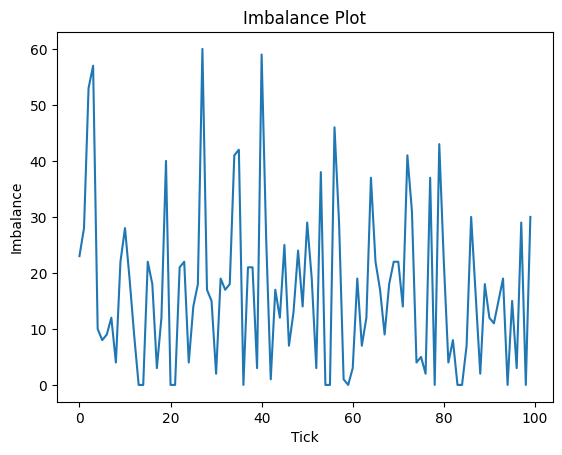

In [51]:
plt.plot(imbalances)
plt.title("Imbalance Plot")
plt.xlabel("Tick")
plt.ylabel("Imbalance")

(array([15., 14., 20., 13., 10., 11.,  5.,  4.,  4.,  4.]),
 array([ 0.        ,  7.28488216, 14.56976433, 21.85464649, 29.13952866,
        36.42441082, 43.70929299, 50.99417515, 58.27905732, 65.56393948,
        72.84882165]),
 <BarContainer object of 10 artists>)

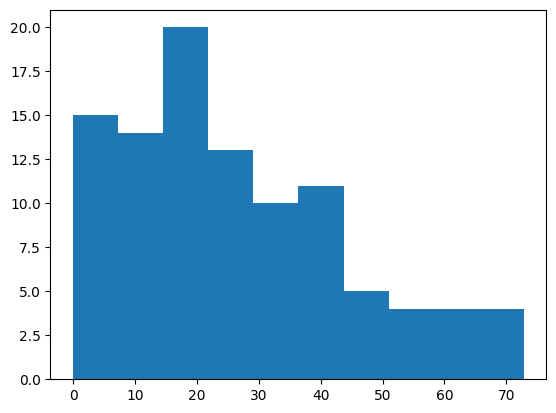

In [52]:
plt.hist(returns)

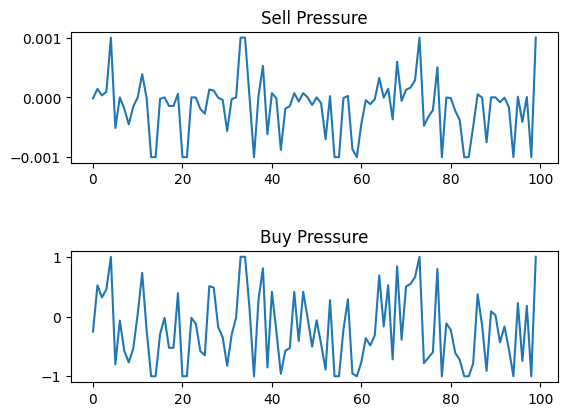

In [53]:
plt.subplot(2, 1, 1)
plt.plot(sell_pressure)
plt.title("Sell Pressure")

plt.subplot(2, 1, 2)
plt.plot(buy_pressure)
plt.title("Buy Pressure")
plt.tight_layout(pad=3.0)  # adds spacing

plt.show()